In [1]:
# Configuración COSMIC v0.0.1 - Estructura Modular
import sys
from pathlib import Path

# Configuración automática de rutas relativas
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parents[2]  # Tres niveles arriba desde data/test/NGC6383/

# Agregar al path si no está
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"COSMIC v0.0.1 - NGC6383 Analysis")
print(f"Directorio actual: {CURRENT_DIR}")
print(f"Proyecto: {PROJECT_ROOT}")

# Verificar instalación de COSMIC
try:
    import cosmic
    print("COSMIC modular disponible")
except ImportError:
    print("Instalando COSMIC...")
    import os
    os.system(f"pip install -e {PROJECT_ROOT}")
    import cosmic
    print("COSMIC instalado")

COSMIC v0.0.1 - NGC6383 Analysis
Directorio actual: /Users/notluquis/COSMIC/data/test/NGC6383
Proyecto: /Users/notluquis/COSMIC
COSMIC modular disponible


In [2]:
# Imports usando la nueva estructura modular
from cosmic.analysis.analyzer import ClusterAnalyzer

# El import legacy sigue funcionando para compatibilidad:
# from COSMIC import ClusterAnalyzer  # Funciona igual

print(f"ClusterAnalyzer importado: {ClusterAnalyzer}")
print(f"Listo para análisis con nueva API modular")

ClusterAnalyzer importado: <class 'cosmic.analysis.analyzer.ClusterAnalyzer'>
Listo para análisis con nueva API modular


In [3]:
# Configuración de datos usando rutas relativas
data_folder = 'data/40/'
file_path = data_folder + 'clustering_results.dill'

print(f"Carpeta de datos: {data_folder}")
print(f"Archivo: {file_path}")
print(f"Existe: {Path(file_path).exists()}")

# Inicializar el analizador con la nueva API
ca = ClusterAnalyzer(file_path)
print("ClusterAnalyzer inicializado correctamente")

Carpeta de datos: data/40/
Archivo: data/40/clustering_results.dill
Existe: True


DataLoader initialized with file path: /Users/notluquis/COSMIC/data/test/NGC6383/data/40/clustering_results.dill


ClusterAnalyzer inicializado correctamente


In [4]:
# 3) Build (or retrieve) a summary table: one row per cluster, 
#    with columns for label, n_members, persistence, etc.
ca.clusters_summary(include_noise=True)

,cluster,count,fraction,persistence,mean_prob,median_prob,min_prob,max_prob,iqr_prob,centroid_pmra,centroid_pmdec,mean_dist2centroid,std_dist2centroid,pmra_range,pmdec_range
0,-1,11957,0.538240,NaN,0.000000,0.000000,0.000000,0.0,0.000000,-1.143355,-3.624370,4.625754,3.889289,65.092520,91.320198
1,0,39,0.001756,0.007670,0.990745,1.000000,0.933498,1.0,0.008619,-0.769029,-10.340236,0.408114,0.159745,1.113640,1.197941
2,1,40,0.001801,0.010913,0.990900,1.000000,0.937103,1.0,0.007917,0.114450,-6.693713,0.311966,0.137088,0.618222,0.962831
3,2,35,0.001576,0.016950,0.993068,1.000000,0.920344,1.0,0.000000,-4.152612,-6.244224,0.213020,0.122957,0.694066,0.763572
4,3,33,0.001485,0.006803,0.999119,1.000000,0.980208,1.0,0.000000,-2.517541,-0.475903,0.215459,0.092621,0.396503,0.775694
5,4,66,0.002971,0.017990,0.977739,0.964883,0.918642,1.0,0.035117,-1.407462,-5.845631,0.275323,0.086398,0.604752,0.795330
6,5,40,0.001801,0.025743,0.980952,1.000000,0.899858,1.0,0.010888,1.363101,-3.825059,0.217163,0.073988,0.417512,0.587454
7,6,31,0.001395,0.003179,0.999307,1.000000,0.988608,1.0,0.000000,-2.593448,-5.856634,0.229397,0.107535,0.708978,0.565946
8,7,33,0.001485,0.005682,0.998909,1.000000,0.981007,1.0,0.000000,1.007894,-4.530571,0.243295,0.109613,0.537902,0.783836
9,8,30,0.001350,0.007823,0.999574,1.000000,0.987214,1.0,0.000000,1.825015,0.563939,0.150388,0.069100,0.343345,0.576047


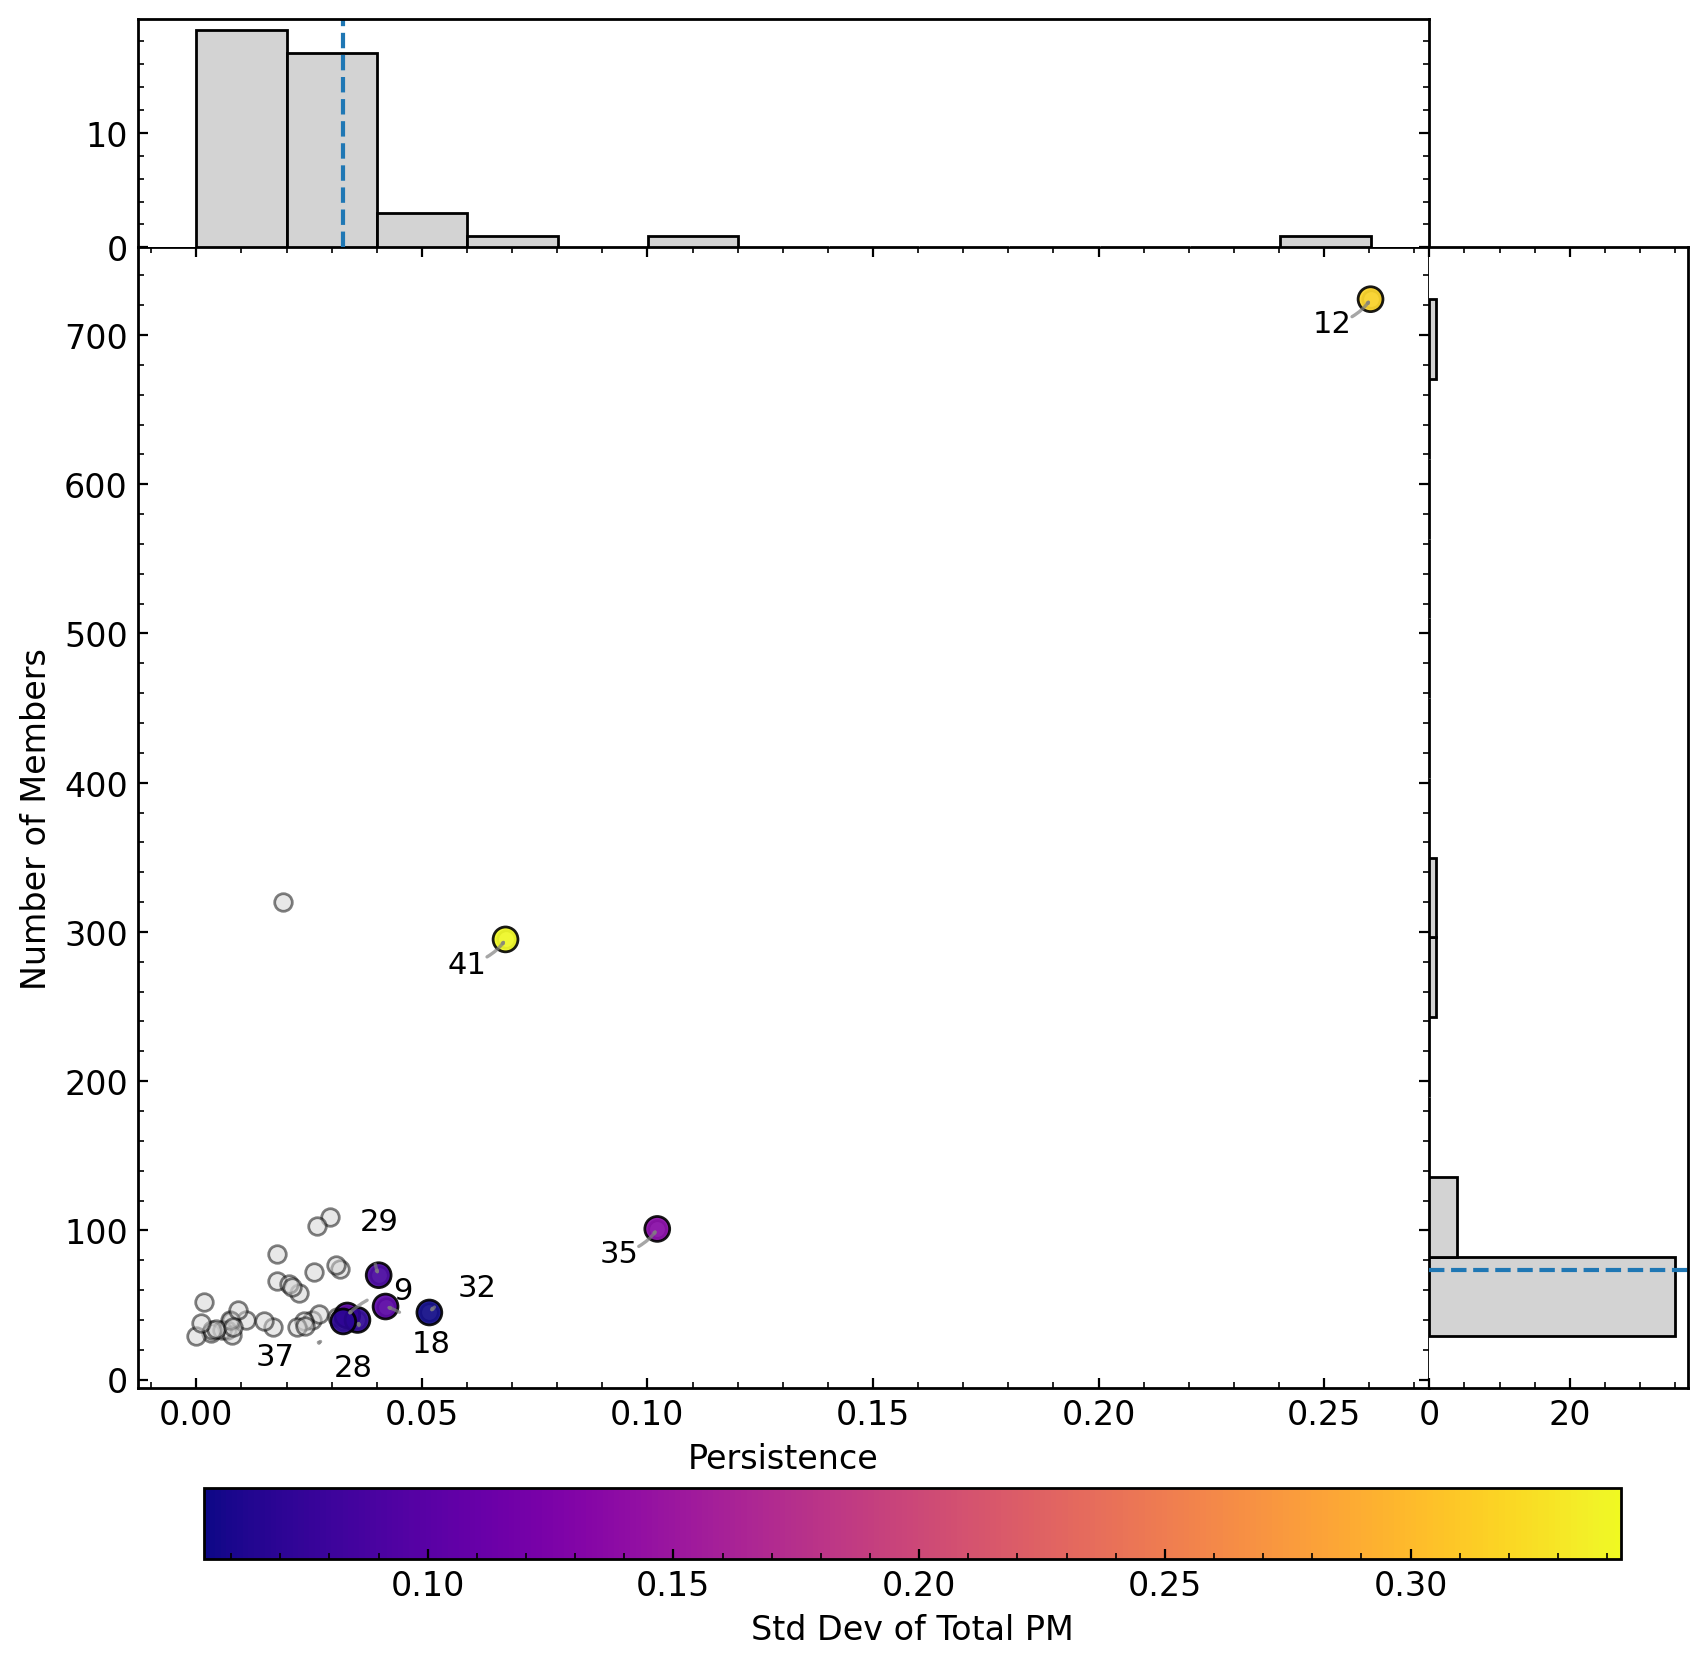

In [5]:
ca.plot_persistence_vs_members(percentile=0.8, figsize=(10,10))

In [6]:
cluster_id = 12
cluster_data = ca.select_cluster(cluster_id)  # esto devuelve solo los objetos de ese cluster
print(f"Cluster {cluster_id} selected, contains {len(cluster_data)} sources.")

Cluster 12 selected, contains 724 sources.


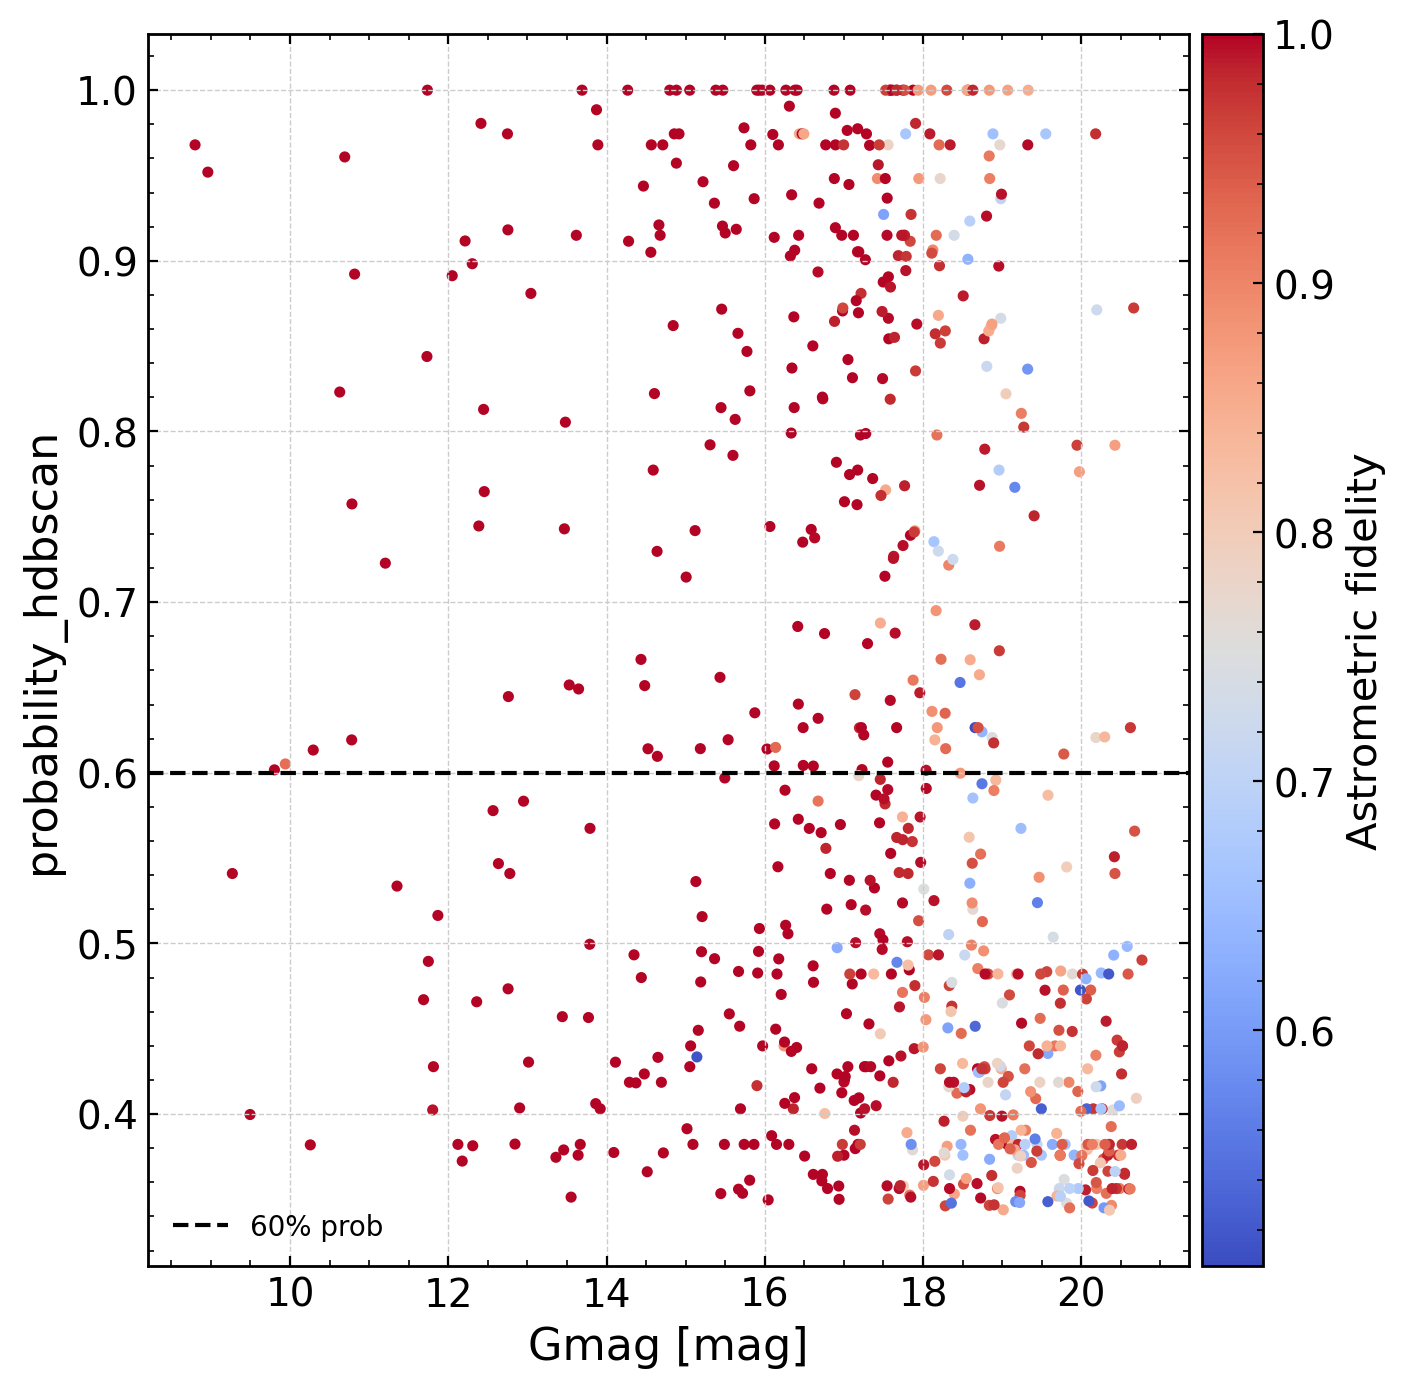

In [7]:
ca.plot_probability_vs_gmag(figsize=(8,8)) # a esto no se la ha hecho nada, es el cluster tal cual como slió del preprocessing.

In [8]:
pmin = 0.5
pre = (ca.data['probability_hdbscan'] >= pmin)

In [9]:
ca.sigma_clip_parallax(
    sigma=2.0,
    use_biweight=True,
    preselector_mask=pre,
    print_results=True,
    in_place=True
)

724 before sigma clipping
331 after sigma clipping


(<Quantity 0.77425011 mas>, <Quantity 1.0510457 mas>)

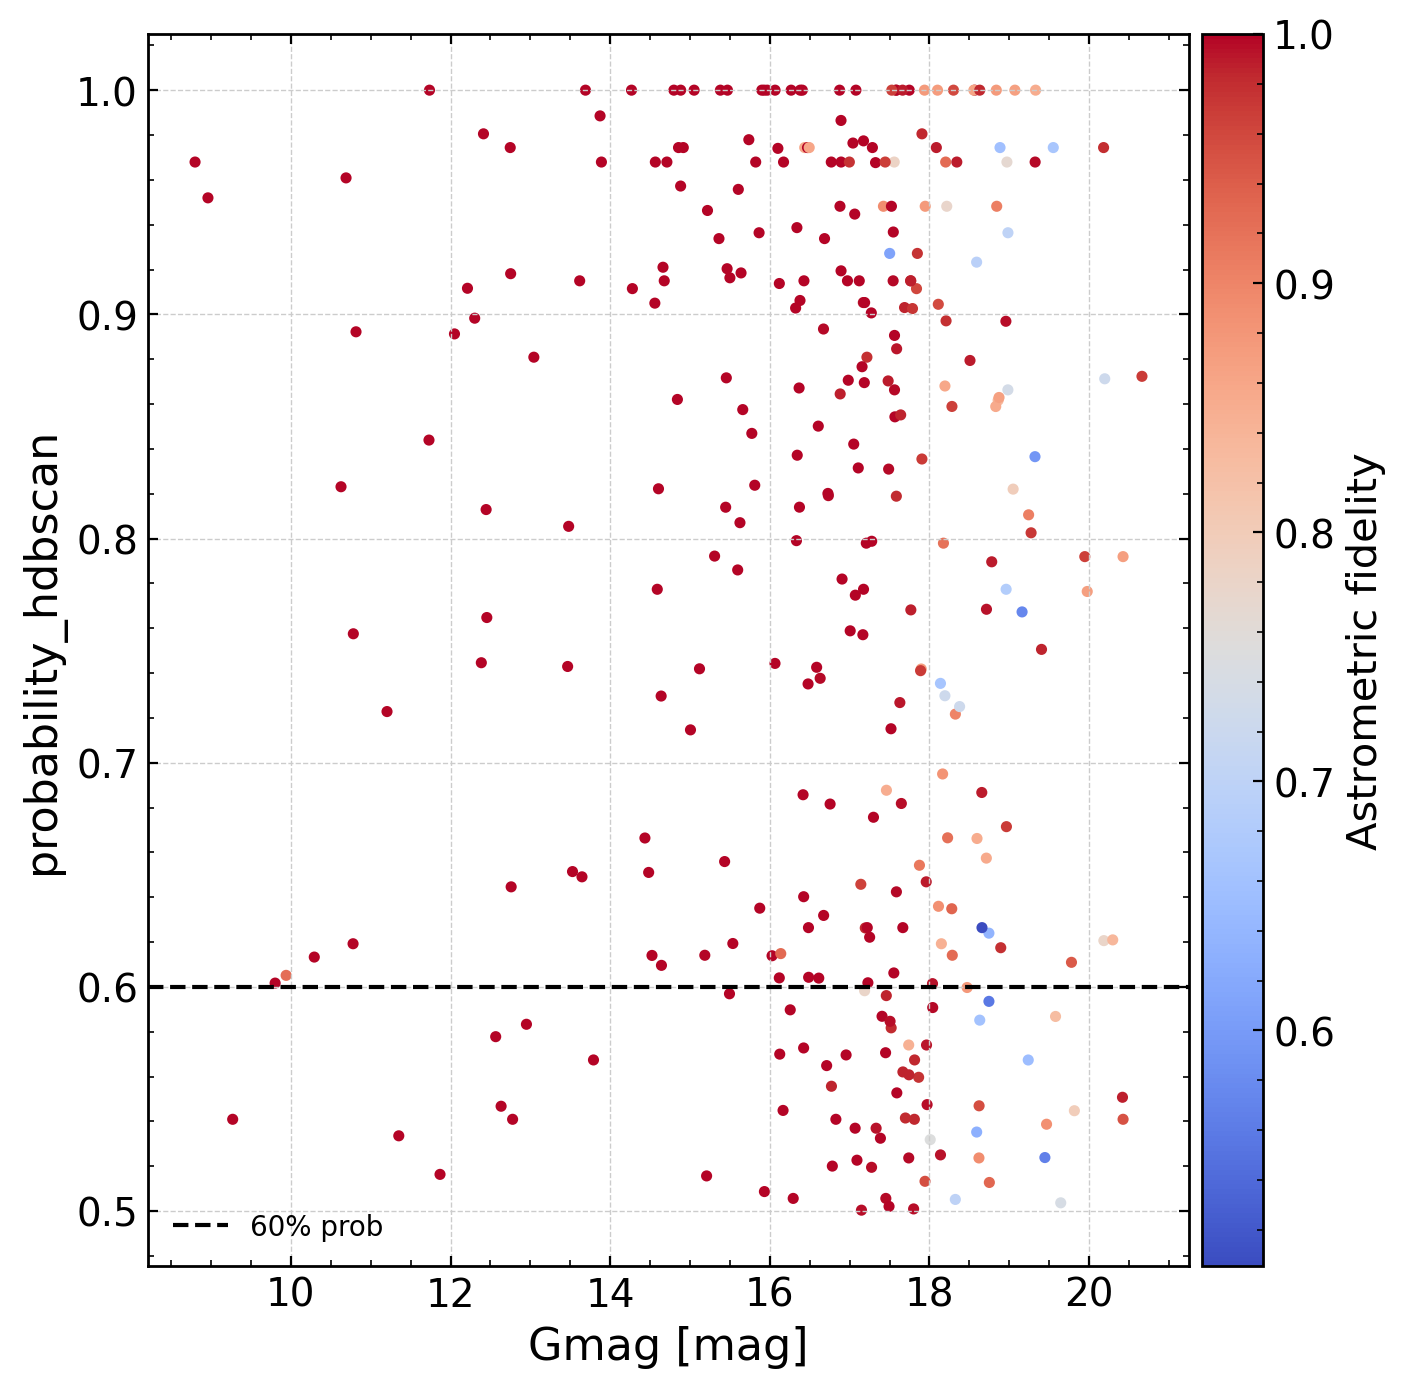

In [10]:
ca.plot_probability_vs_gmag(figsize=(8,8))

In [11]:
ca.pms_characterization(
)

/Users/notluquis/COSMIC/cosmic/analysis/analyzer.py:198: UserWarning: [pms_characterization] Input data has changed since the last Sagitta run but run_cli=False. Loading stale results from cluster_12_sagitta-sagitta.fits. Re-run with run_cli=True to update.
  joined = _pms_characterization(


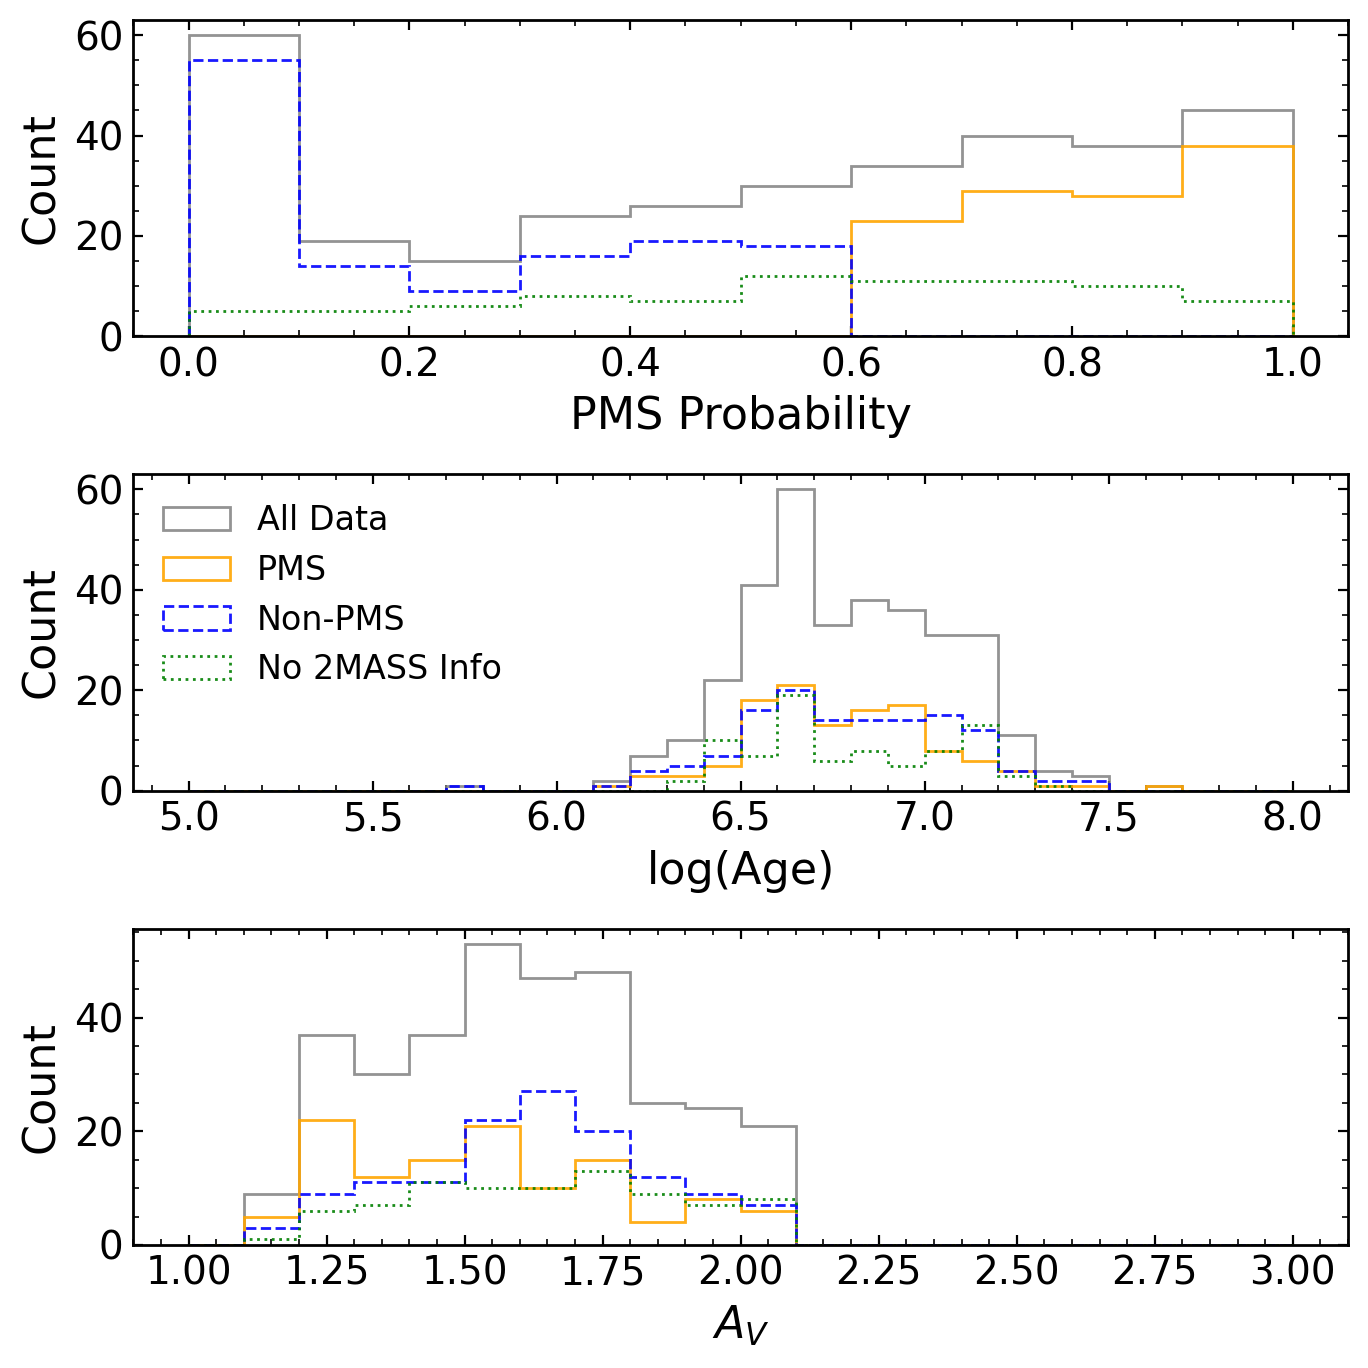

In [12]:
ca.plot_pms(
    cluster=cluster_id,
    pms_threshold=0.6,    # ajusta si deseas un corte distinto
    figsize=(7,7),
    layout="tight",
)

In [13]:
cluster_data = ca.select_cluster(cluster_id)

In [15]:
fitter = ca.prepare_isochrone_fitter(
    cluster=cluster_id,
    isochs_path="./MIST/UBVRIplus/",
)

In [16]:
# 2. Actualiza los priors ANTES de build_grid
fitter.set_priors({
    "dm_mu":      10.204,
    "dm_sigma":   0.05,
    "dm_range":   (9.95, 10.45),
    "Av_range":   (0.0, 1.5),
    "loga_range": (6.0, 6.5),
})

In [17]:
# 3. Construye la grilla (usa los priors actualizados para el rango)
fitter.build_grid(
    M_met=15,
    M_loga=107,
    grid_cache="./data/40/hgrid_v3.npz",
)

  H_grid: 1000/1605 (62%)
  H_grid complete: (15, 107, 15, 14)
H_grid saved to: ./data/40/hgrid_v3.npz


In [18]:
# 4. Fit
idata = fitter.fit(
    draws=5000,
    tune=2000,
    nuts_sampler="blackjax",
    initvals={"met": 0.008033, "dm": 10.204, "Av": 0.3},
)

/Users/notluquis/miniforge3/envs/cosmic/lib/python3.14/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
W0327 00:10:07.253518 1766134 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Running window adaptation


<div><progress max="2000" value="2000"></progress> 100.00% [2000/2000 00:00&lt;?]</div>

<div><progress max="2000" value="2000"></progress> 100.00% [2000/2000 00:00&lt;?]</div>

<div><progress max="2000" value="2000"></progress> 100.00% [2000/2000 00:00&lt;?]</div>

...

<div><progress max="5000" value="5000"></progress> 100.00% [5000/5000 00:00&lt;?]</div>

<div><progress max="5000" value="5000"></progress> 100.00% [5000/5000 00:00&lt;?]</div>

<div><progress max="5000" value="5000"></progress> 100.00% [5000/5000 00:00&lt;?]</div>

<div><progress max="5000" value="5000"></progress> 100.00% [5000/5000 00:00&lt;?]</div>

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [19]:
import arviz as az
az.summary(idata, var_names=["met", "loga", "dm", "Av"], round_to=4)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
met,0.0077,0.0012,0.0059,0.0097,0.0001,0.0000,561.2011,1034.7612,1.0069
loga,6.1077,0.0490,6.0268,6.1957,0.0025,0.0021,346.6089,305.5860,1.0107
dm,10.2160,0.0336,10.1560,10.2710,0.0016,0.0011,459.7733,855.7740,1.0081
Av,0.0299,0.0268,0.0000,0.0787,0.0011,0.0009,582.8870,1016.2956,1.0060


In [20]:
divs = idata.sample_stats["diverging"].values.sum()
print(f"Divergencias: {divs}")
print(f"Draws totales: {idata.posterior.dims}")
print(f"\nR-hat por parámetro:")
for var in ["met", "loga", "dm", "Av", "log_s", "bg"]:
    try:
        rhat = az.rhat(idata)[var].values.item()
        ess  = az.ess(idata)[var].values.item()
        print(f"  {var:8s}  r_hat={rhat:.4f}  ess={ess:.0f}")
    except Exception as e:
        print(f"  {var}: {e}")


Divergencias: 0
Draws totales: FrozenMappingWarningOnValuesAccess({'chain': 4, 'draw': 5000})

R-hat por parámetro:
  met       r_hat=1.0069  ess=561
  loga      r_hat=1.0107  ess=347
  dm        r_hat=1.0081  ess=460
  Av        r_hat=1.0060  ess=583
  log_s     r_hat=1.0034  ess=898
  bg        r_hat=1.0047  ess=759


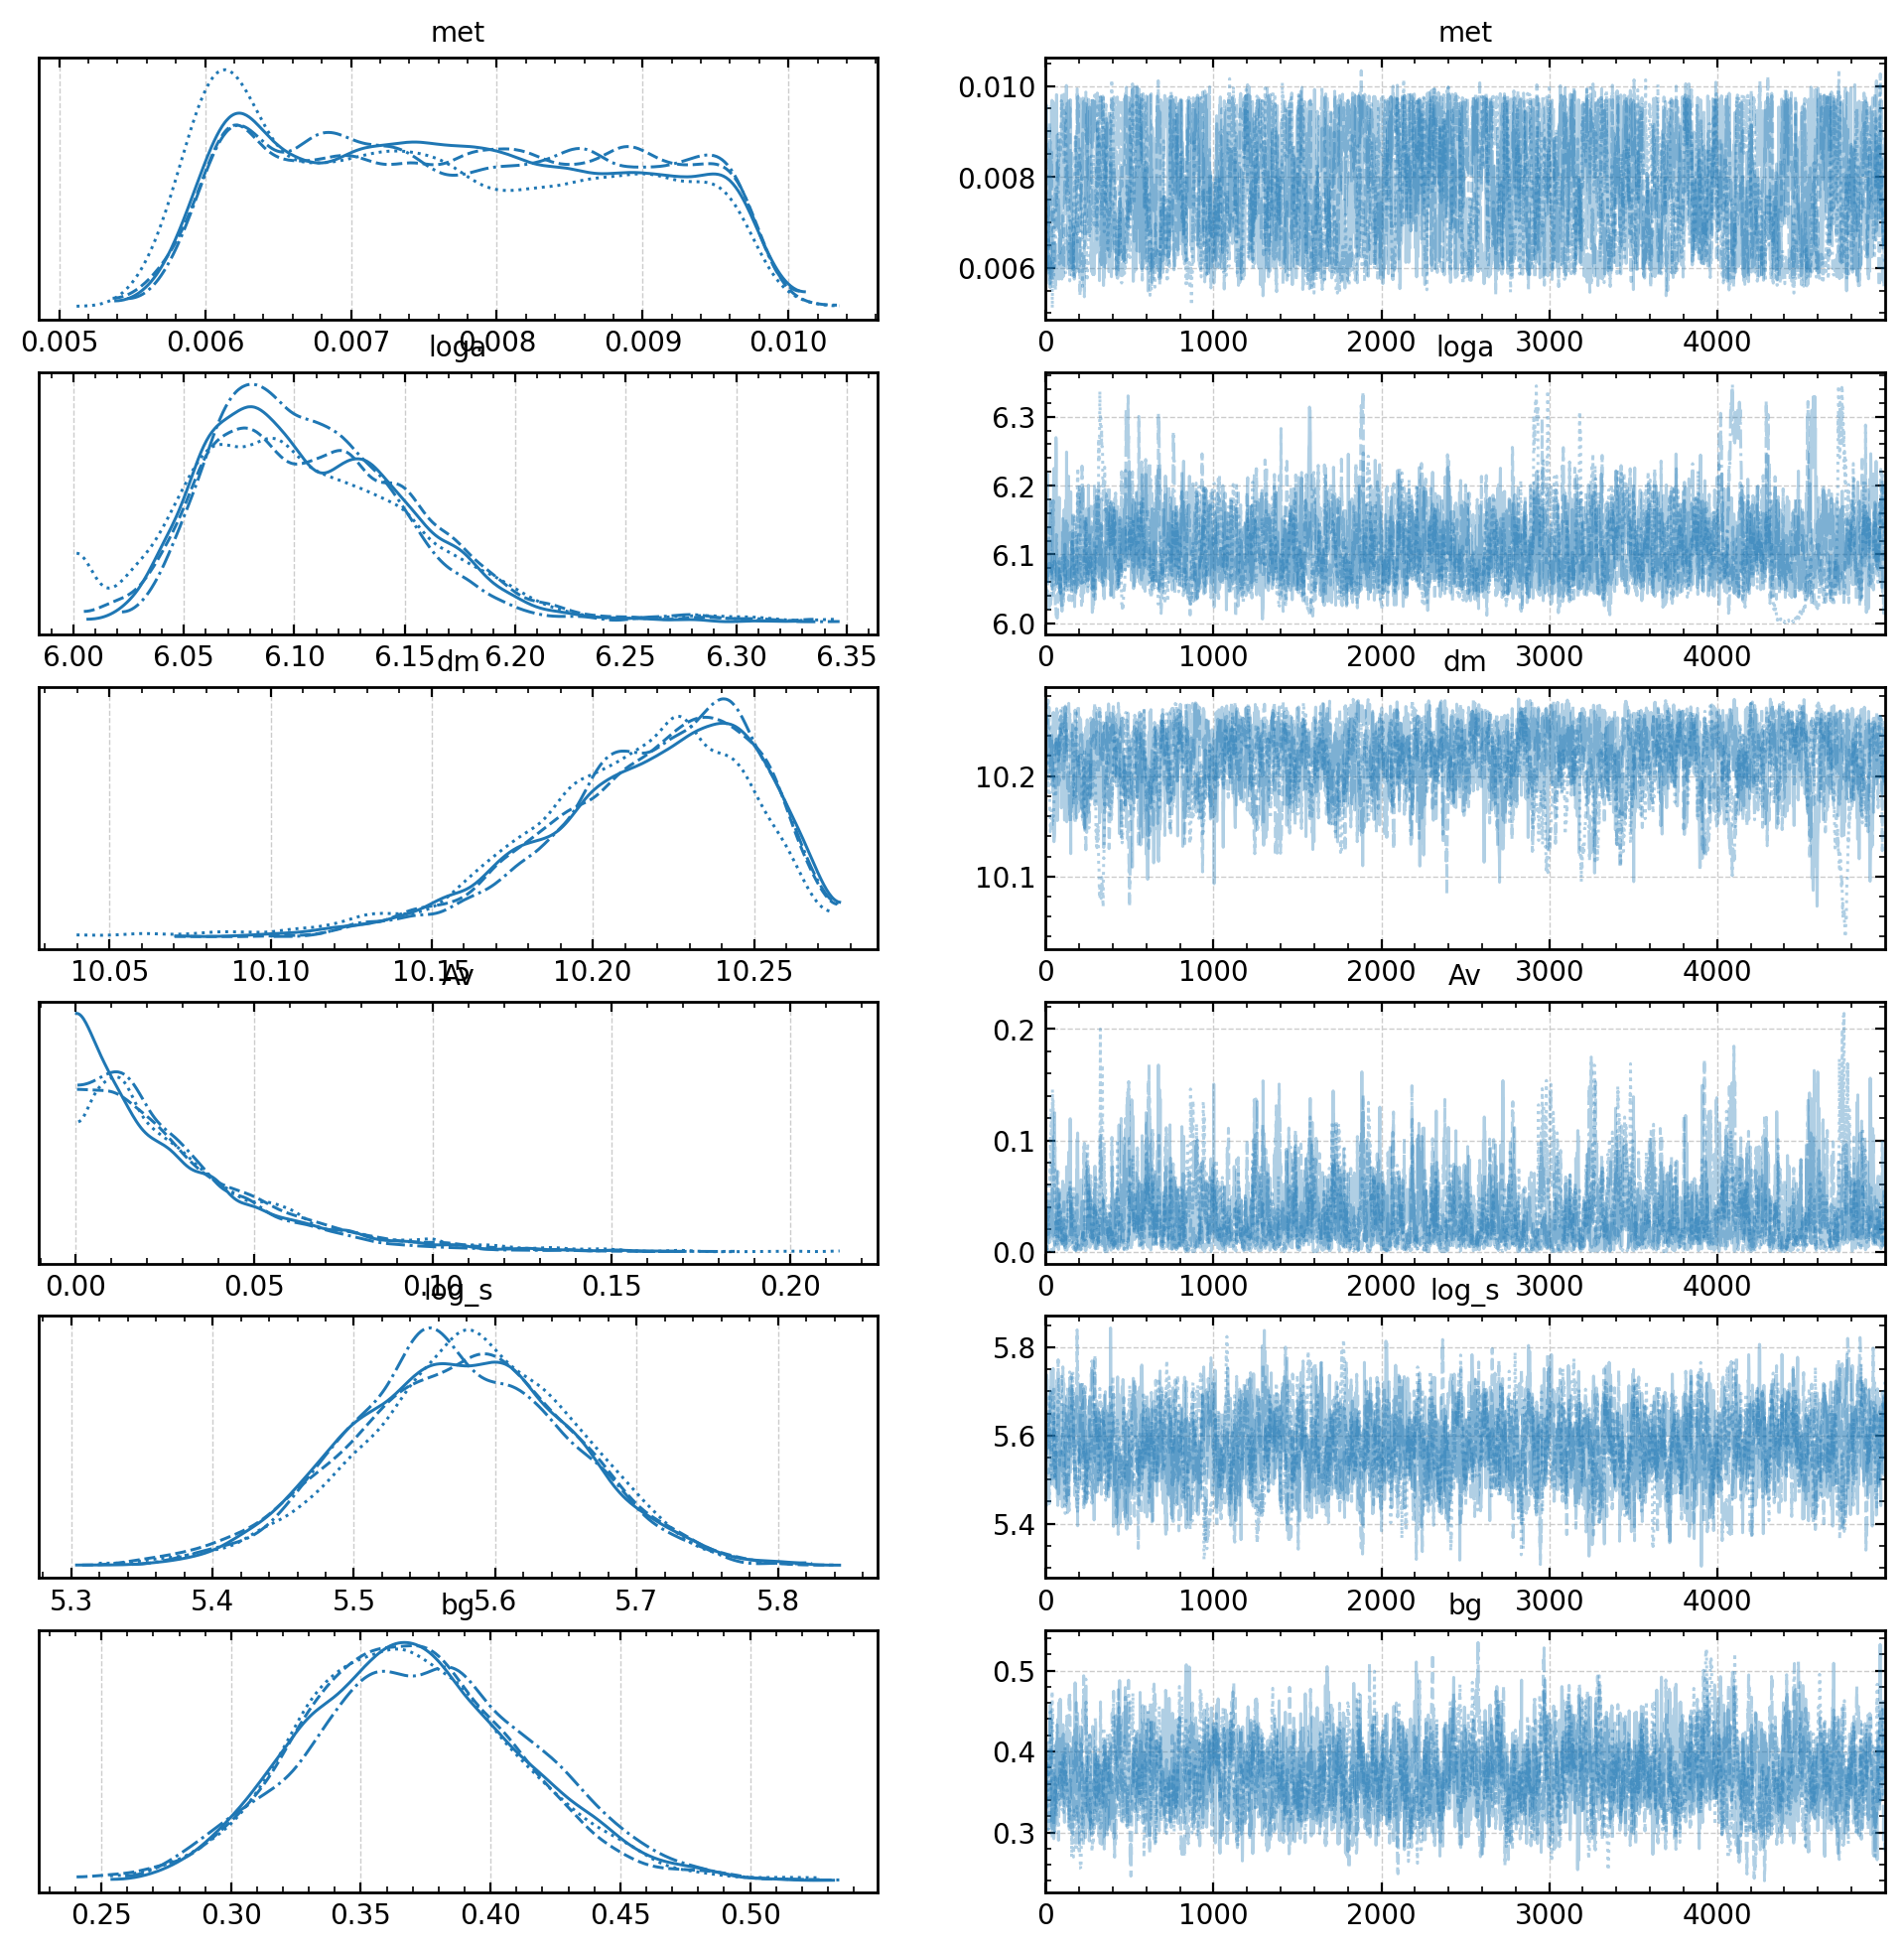

In [21]:
az.plot_trace(idata, var_names=["met", "loga", "dm", "Av", "log_s", "bg"]);


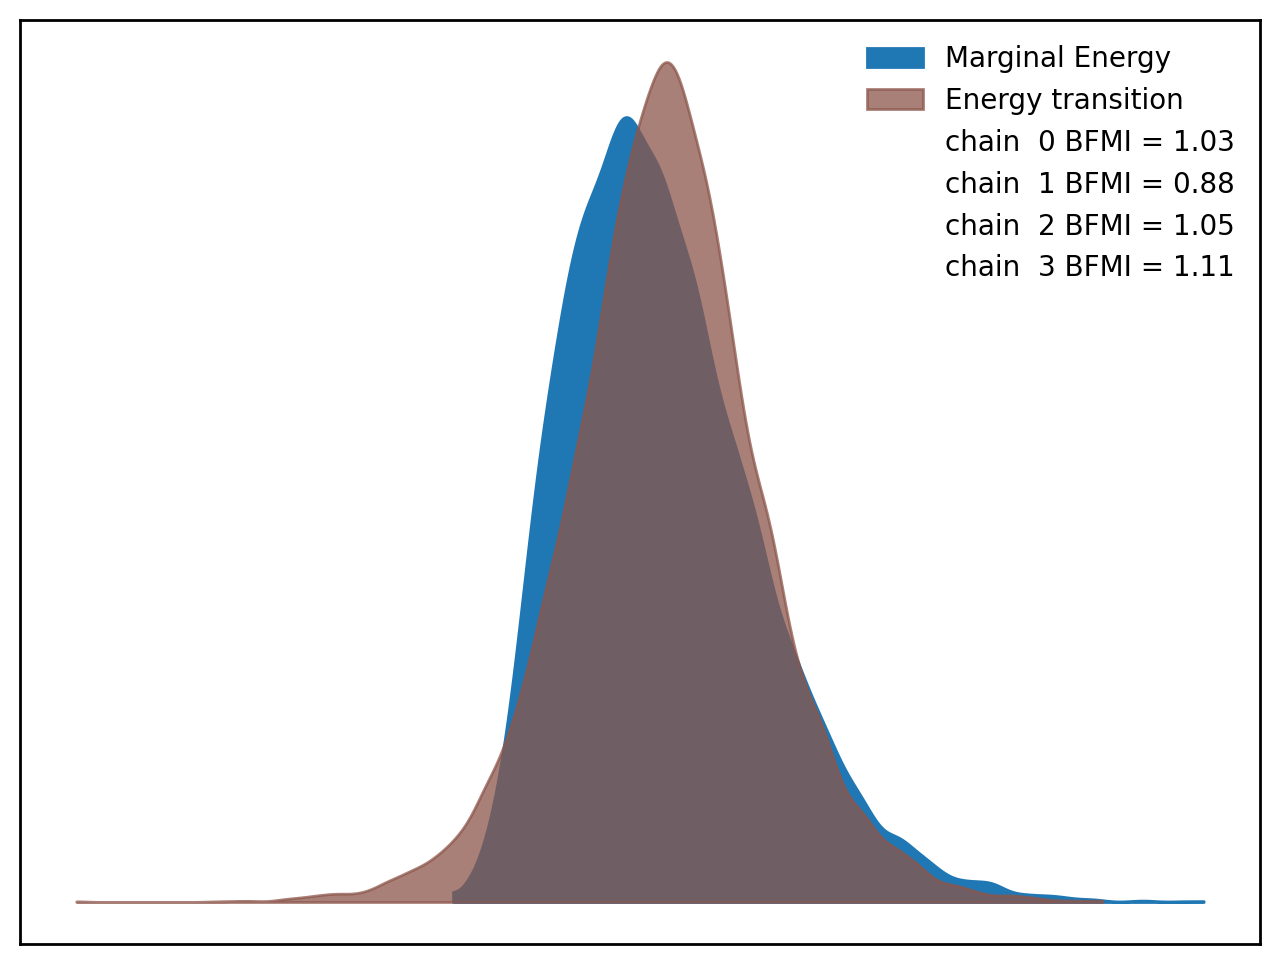

In [22]:
az.plot_energy(idata);

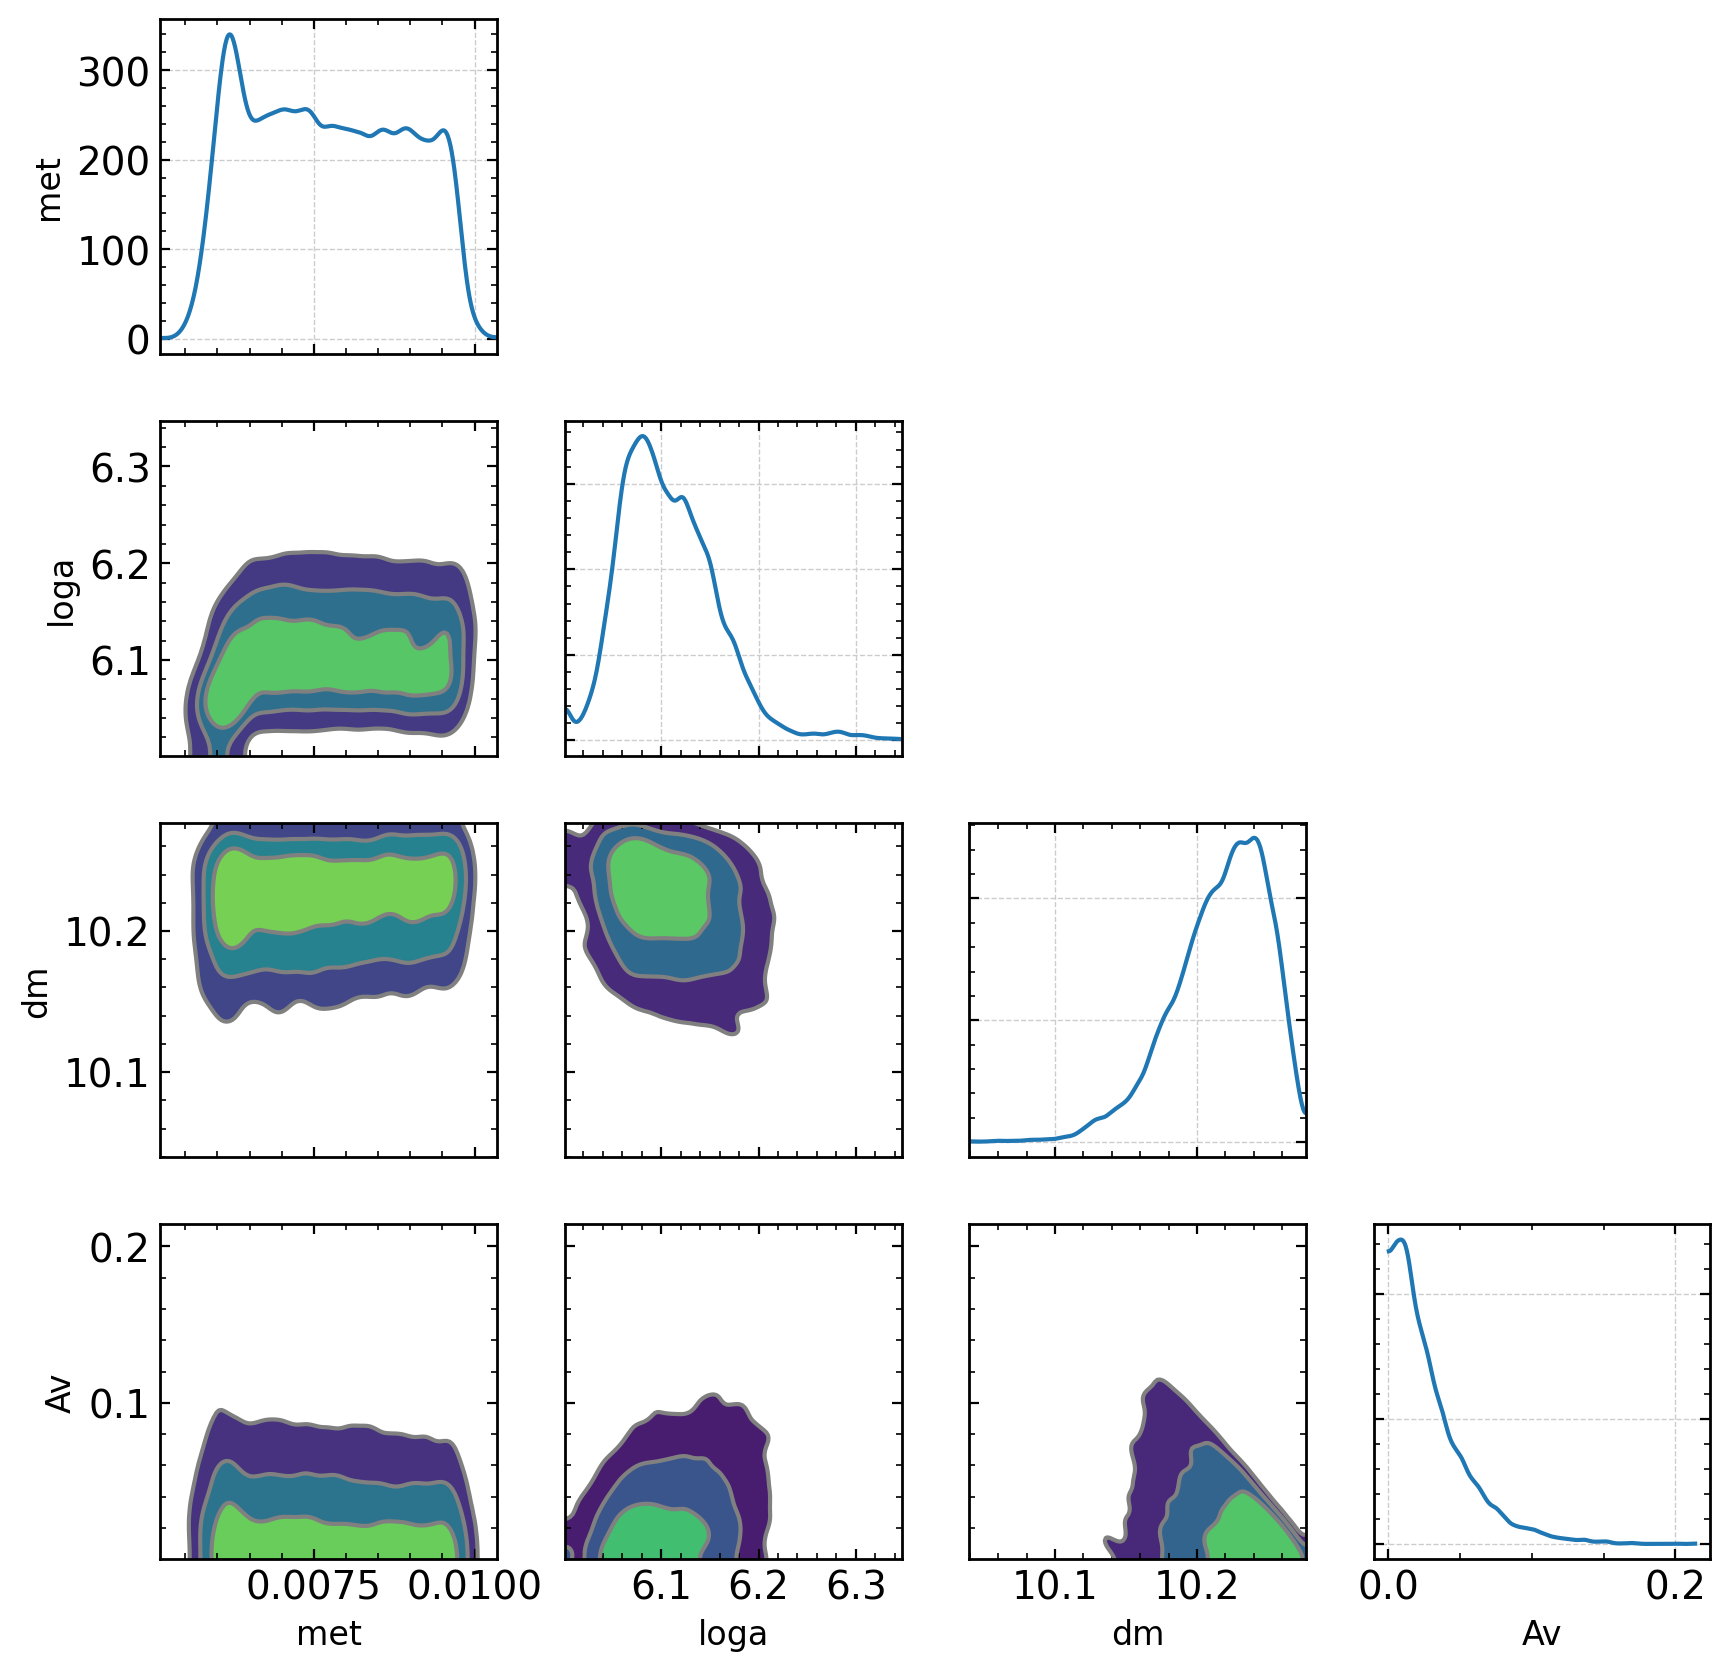

In [23]:
az.plot_pair(
    idata,
    var_names=["met", "loga", "dm", "Av"],
    kind="kde",
    divergences=True,
    marginals=True,
    figsize=(10, 10),
);


In [24]:
print(fitter._isochs.met_age_dict)
print(f"met_min = {fitter._met_grid[0]:.6f}, met_max = {fitter._met_grid[-1]:.6f}")
print(f"Unique Hess diagrams: {len(set(map(tuple, fitter._H_grid.reshape(fitter._H_grid.shape[0]*fitter._H_grid.shape[1], -1))))}")


{'met': array([1.0000e-06, 5.0000e-06, 1.4000e-05, 4.5000e-05, 1.4300e-04,
       2.5400e-04, 4.5200e-04, 8.0300e-04, 1.4290e-03, 2.5400e-03,
       4.5180e-03, 8.0330e-03, 1.4286e-02, 2.5404e-02, 4.5175e-02]), 'loga': array([ 5.  ,  5.05,  5.1 ,  5.15,  5.2 ,  5.25,  5.3 ,  5.35,  5.4 ,
        5.45,  5.5 ,  5.55,  5.6 ,  5.65,  5.7 ,  5.75,  5.8 ,  5.85,
        5.9 ,  5.95,  6.  ,  6.05,  6.1 ,  6.15,  6.2 ,  6.25,  6.3 ,
        6.35,  6.4 ,  6.45,  6.5 ,  6.55,  6.6 ,  6.65,  6.7 ,  6.75,
        6.8 ,  6.85,  6.9 ,  6.95,  7.  ,  7.05,  7.1 ,  7.15,  7.2 ,
        7.25,  7.3 ,  7.35,  7.4 ,  7.45,  7.5 ,  7.55,  7.6 ,  7.65,
        7.7 ,  7.75,  7.8 ,  7.85,  7.9 ,  7.95,  8.  ,  8.05,  8.1 ,
        8.15,  8.2 ,  8.25,  8.3 ,  8.35,  8.4 ,  8.45,  8.5 ,  8.55,
        8.6 ,  8.65,  8.7 ,  8.75,  8.8 ,  8.85,  8.9 ,  8.95,  9.  ,
        9.05,  9.1 ,  9.15,  9.2 ,  9.25,  9.3 ,  9.35,  9.4 ,  9.45,
        9.5 ,  9.55,  9.6 ,  9.65,  9.7 ,  9.75,  9.8 ,  9.85,  9.9 ,
        9.9

In [25]:
print(f"dm_mu    = {fitter.dm_mu}")
print(f"dm_sigma = {fitter.dm_sigma}")
print(f"dm_range = {fitter.dm_range}")
print(f"Av_range = {fitter.Av_range}")
print(f"loga_range = {fitter.loga_range}")


dm_mu    = 10.204
dm_sigma = 0.05
dm_range = (9.95, 10.45)
Av_range = (0.0, 1.5)
loga_range = (6.0, 6.5)


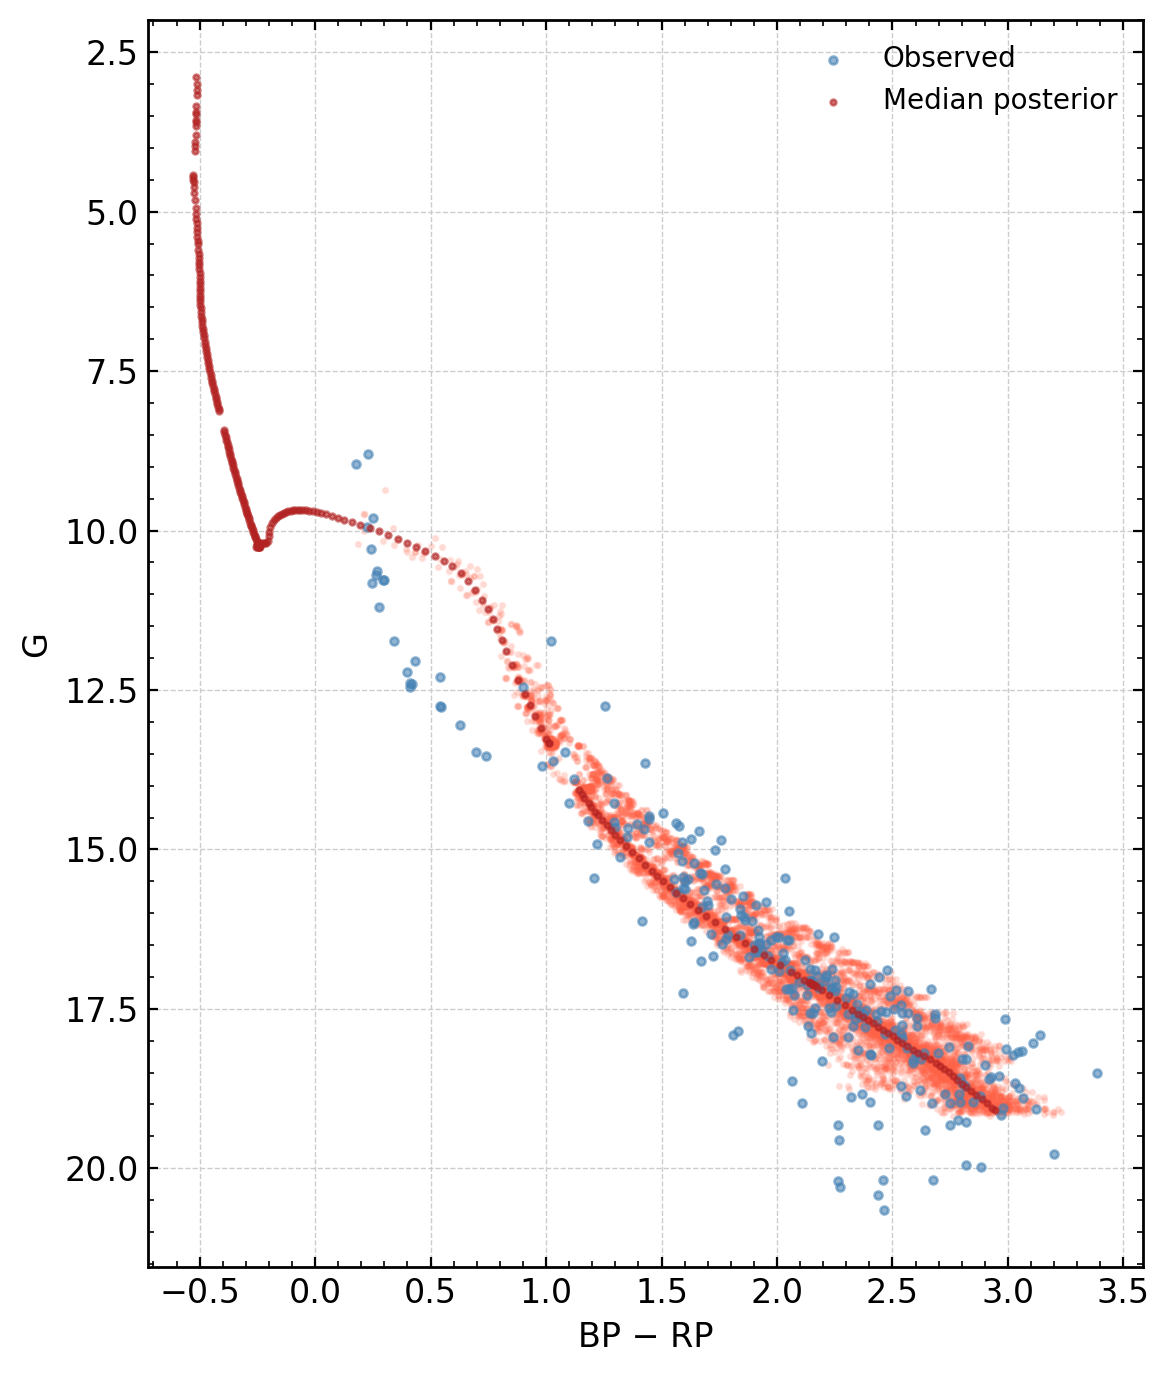

In [29]:
fitter.plot_cmd(idata, num_samples=30)

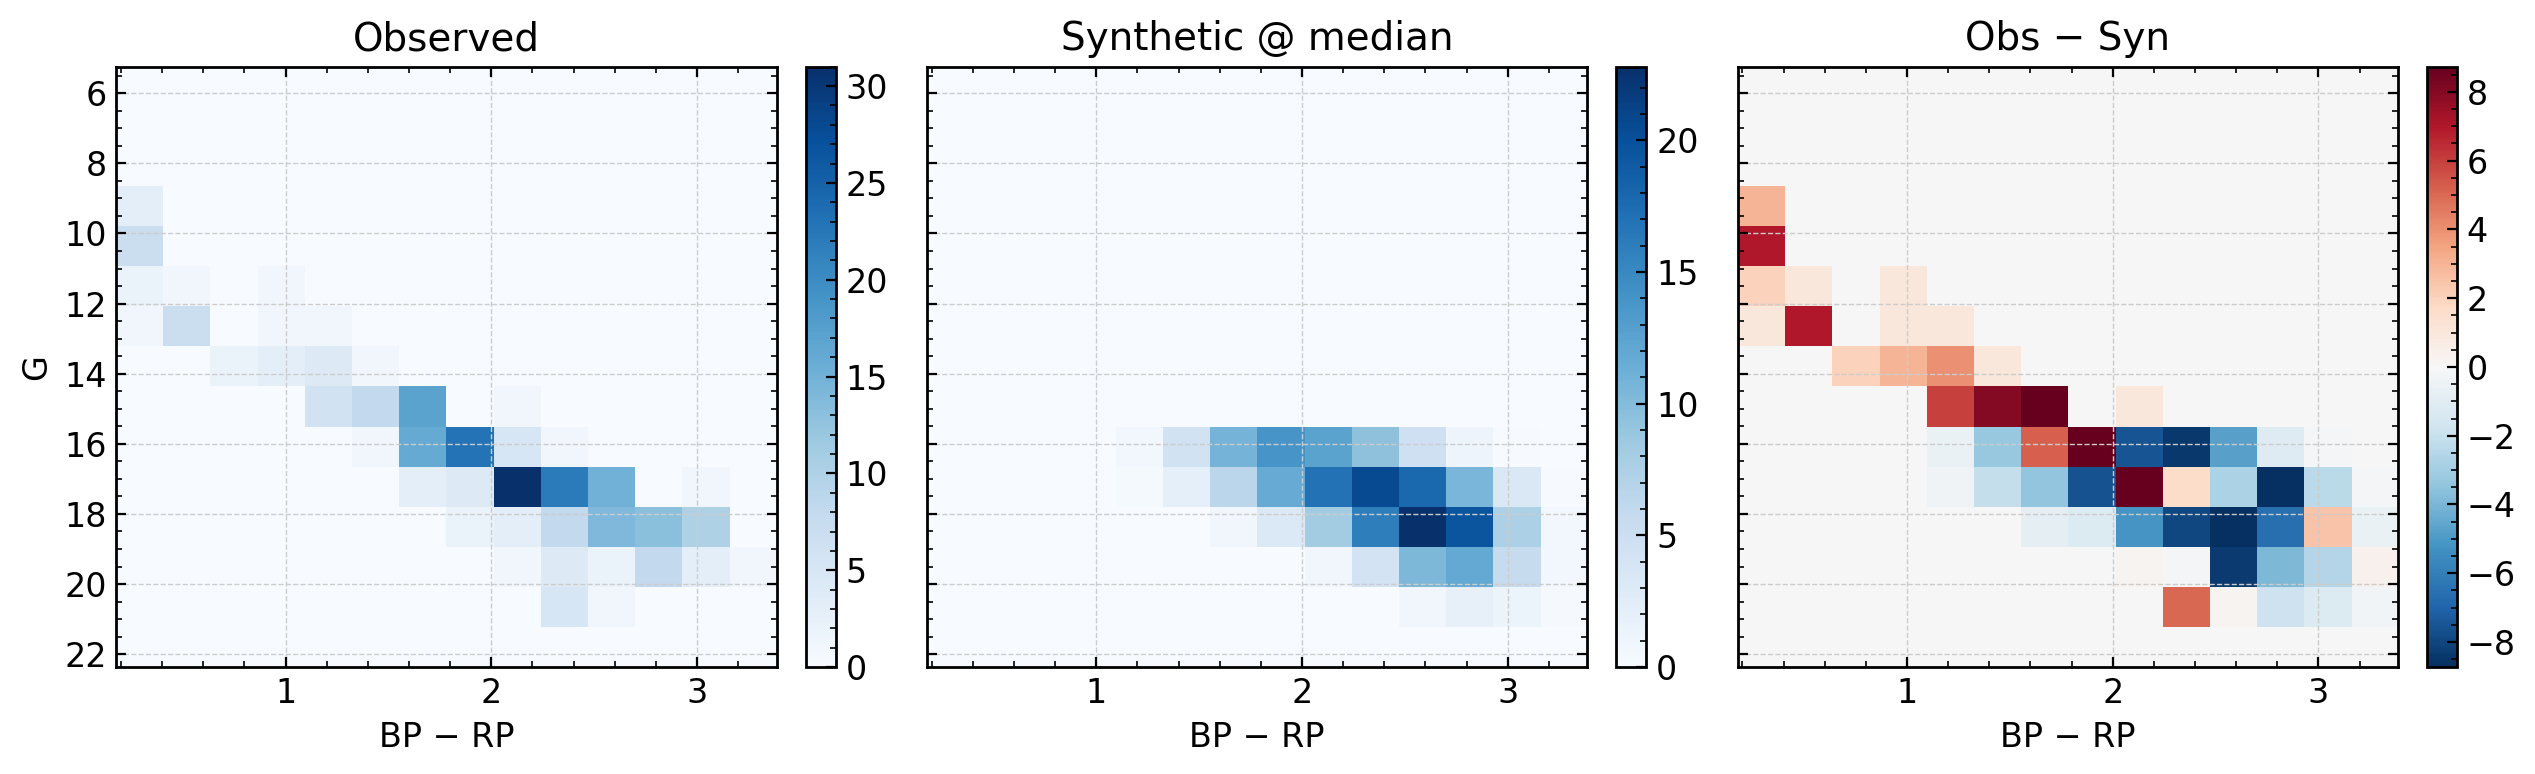

In [31]:
importlib.reload(_iso_mod)
fitter.plot_hess = types.MethodType(_iso_mod.IsochroneFitter.plot_hess, fitter)

fitter.plot_hess(idata)
